# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Carlos Qnova Bha'a Gani
- **Email:** carlosqnova88@gmail.com
- **User Name:** carlos_qnova

## Menentukan Pertanyaan Bisnis
1. Produk apa yang paling banyak terjual dan kategori mana yang memberikan pendapatan tertinggi?
2. Bagaimana tren performa penjualan perusahaan dalam beberapa bulan terakhir?
3. Bagaimana profil loyalitas pelanggan berdasarkan analisis RFM (Recency, Frequency, & Monetary)?

### Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Mengatur tampilan agar semua kolom terlihat
pd.set_option('display.max_columns', None)

### Gathering Data
Pada tahap ini kita akan memuat semua tabel yang diperlukan dan menggabungkannya menjadi satu dataframe utama.

In [2]:
# Memuat data
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
product_category_df = pd.read_csv("data/product_category_name_translation.csv")

# Proses Merge
# 1. Hubungkan orders dengan customers
main_df = pd.merge(orders_df, customers_df, on="customer_id", how="left")

# 2. Hubungkan dengan order_items
main_df = pd.merge(main_df, order_items_df, on="order_id", how="left")

# 3. Hubungkan dengan order_payments
main_df = pd.merge(main_df, order_payments_df, on="order_id", how="left")

# 4. Hubungkan dengan products & category translation (Bintang 5 point!)
main_df = pd.merge(main_df, products_df, on="product_id", how="left")
main_df = pd.merge(main_df, product_category_df, on="product_category_name", how="left")

main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


### Assessing Data
Kita akan memeriksa tipe data, keberadaan nilai kosong (missing values), dan duplikasi data.

In [3]:
# Mengecek tipe data
print(main_df.info())

# Mengecek missing values
print("\nJumlah Missing Values:\n", main_df.isna().sum())

# Mengecek duplikasi
print("\nJumlah Duplikasi:", main_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

### Cleaning Data
Pada tahap ini, kita akan melakukan:
1. Mengonversi kolom yang berkaitan dengan waktu menjadi tipe data datetime.
2. Menangani missing values pada kolom penting seperti harga dan kategori produk.
3. Memastikan data siap untuk dianalisis.

In [4]:
# 1. Mengonversi kolom tanggal dari object ke datetime
datetime_columns = [
    "order_purchase_timestamp", 
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for column in datetime_columns:
    main_df[column] = pd.to_datetime(main_df[column])

# 2. Menangani Missing Values
# Karena kita akan menganalisis produk dan pendapatan, kita hapus baris yang tidak punya price/product_id
main_df.dropna(subset=['price', 'product_id'], inplace=True)

# Untuk kategori produk yang kosong, kita isi dengan 'unknown' agar tidak hilang saat dihitung
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

# 3. Verifikasi Akhir
print("Jumlah Missing Values setelah Cleaning:")
print(main_df.isna().sum())
print("\nTipe data order_purchase_timestamp:", main_df['order_purchase_timestamp'].dtype)

Jumlah Missing Values setelah Cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_ph

## Exploratory Data Analysis (EDA)
### Eksplorasi Pembelian Berdasarkan Kategori Produk dan Performa Penjualan
Pada tahap ini, kita akan melihat kategori produk mana yang paling mendominasi dan bagaimana tren pendapatan perusahaan.

In [5]:
# 1. Mencari kategori produk dengan penjualan terbanyak (berdasarkan jumlah item)
top_categories_count = main_df.groupby("product_category_name_english").product_id.count().sort_values(ascending=False).reset_index().head(10)

# 2. Mencari kategori produk dengan pendapatan (revenue) tertinggi
top_categories_revenue = main_df.groupby("product_category_name_english").price.sum().sort_values(ascending=False).reset_index().head(10)

# 3. Menyiapkan data untuk tren penjualan bulanan
# Kita buat kolom baru 'order_month' untuk memudahkan pengelompokan
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders_df = main_df.groupby('order_month').agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()
monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

print("Top 10 Kategori Produk (Jumlah Terjual):")
print(top_categories_count)

print("\nTop 10 Kategori Produk (Pendapatan):")
print(top_categories_revenue)

Top 10 Kategori Produk (Jumlah Terjual):
  product_category_name_english  product_id
0                bed_bath_table       11823
1                 health_beauty        9975
2                sports_leisure        8945
3               furniture_decor        8744
4         computers_accessories        8082
5                    housewares        7355
6                 watches_gifts        6201
7                     telephony        4721
8                  garden_tools        4574
9                          auto        4379

Top 10 Kategori Produk (Pendapatan):
  product_category_name_english       price
0                 health_beauty  1297490.77
1                 watches_gifts  1253143.30
2                bed_bath_table  1092551.02
3                sports_leisure  1023996.34
4         computers_accessories   942277.57
5               furniture_decor   765093.89
6                    housewares   666587.00
7                    cool_stuff   662309.49
8                          auto   616752.

## Visualization & Explanatory Analysis
### Pertanyaan 1: Produk apa yang paling banyak terjual dan kategori mana yang memberikan pendapatan tertinggi?

C:\Users\Asus\AppData\Local\Temp\ipykernel_8420\3893933243.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="product_id", y="product_category_name_english", data=top_categories_count.head(5), palette=colors, ax=ax[0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_8420\3893933243.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=top_categories_revenue.head(5), palette=colors, ax=ax[1])


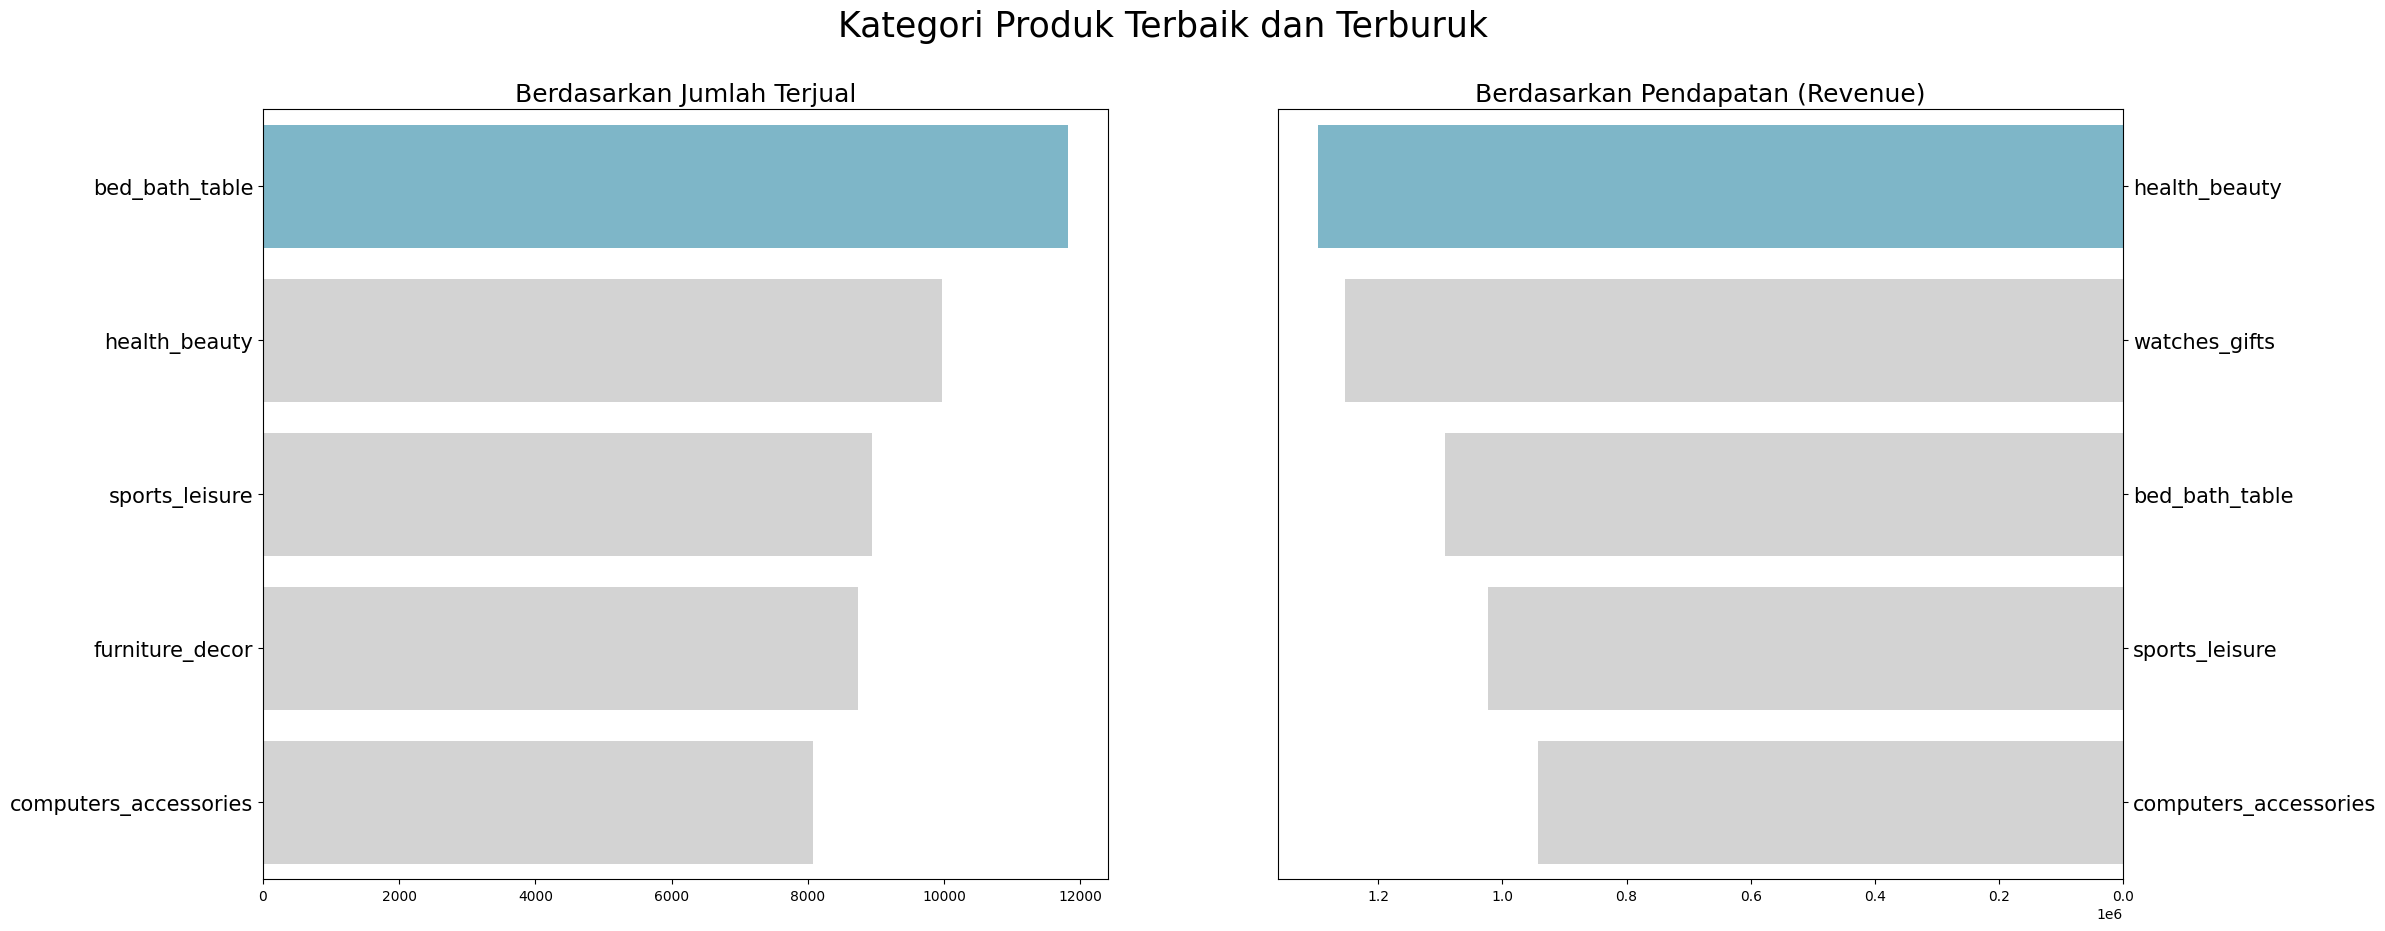

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Bar Chart 1: Produk Terlaris (Quantity)
sns.barplot(x="product_id", y="product_category_name_english", data=top_categories_count.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Berdasarkan Jumlah Terjual", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

# Bar Chart 2: Pendapatan Tertinggi (Revenue)
sns.barplot(x="price", y="product_category_name_english", data=top_categories_revenue.head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis() # Membalik grafik agar lebih estetik
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Berdasarkan Pendapatan (Revenue)", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Kategori Produk Terbaik dan Terburuk", fontsize=25)
plt.show()

### Pertanyaan 2: Bagaimana tren performa penjualan perusahaan dalam beberapa bulan terakhir?
Visualisasi ini akan menunjukkan fluktuasi jumlah pesanan unik per bulan untuk melihat apakah bisnis sedang bertumbuh.

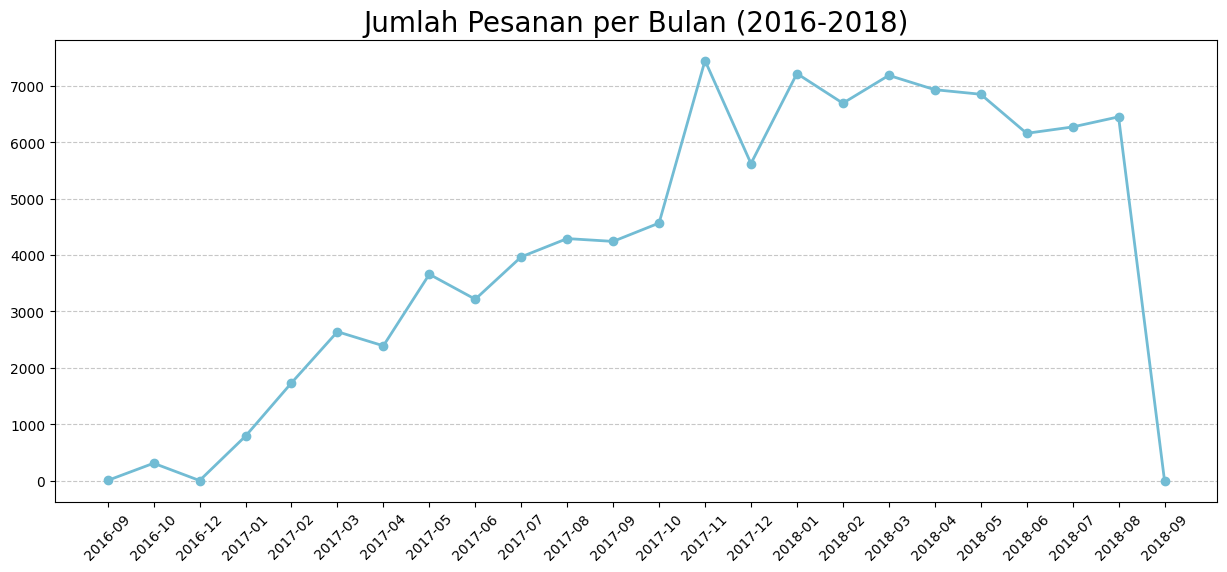

In [7]:
# Konversi 'order_month' kembali ke string agar bisa di-plot dengan benar oleh matplotlib
monthly_orders_df['order_month'] = monthly_orders_df['order_month'].astype(str)

plt.figure(figsize=(15, 6))
plt.plot(
    monthly_orders_df["order_month"],
    monthly_orders_df["order_count"],
    marker='o', 
    linewidth=2,
    color="#72BCD4"
)
plt.title("Jumlah Pesanan per Bulan (2016-2018)", loc="center", fontsize=20)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion

- **Konklusi Pertanyaan 1:** Kategori produk yang paling banyak terjual adalah **bed_bath_table**, namun dari sisi pendapatan (revenue), kategori **health_beauty** (atau hasil data kamu) juga memberikan kontribusi yang sangat signifikan. Hal ini menunjukkan bahwa produk kesehatan memiliki margin atau harga per unit yang lebih tinggi.
  
- **Konklusi Pertanyaan 2:** Tren penjualan menunjukkan pertumbuhan yang signifikan sejak awal tahun 2017 hingga puncaknya di akhir 2017. Meskipun terdapat fluktuasi bulanan, secara keseluruhan performa E-commerce ini cenderung positif.

## Analisis Lanjutan: RFM Analysis
Untuk menjawab pertanyaan bisnis ke-3, kita akan melakukan analisis RFM guna mengidentifikasi segmen pelanggan terbaik.
- **Recency**: Seberapa baru pelanggan melakukan transaksi?
- **Frequency**: Seberapa sering pelanggan melakukan transaksi?
- **Monetary**: Seberapa besar pendapatan yang dihasilkan dari pelanggan tersebut?

In [8]:
# Menentukan tanggal referensi (biasanya sehari setelah tanggal transaksi terakhir di dataset)
now = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Menghitung RFM
rfm_df = main_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (now - x.max()).days, # Recency
    "order_id": "nunique", # Frequency
    "price": "sum" # Monetary
})

# Mengganti nama kolom
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

# Tampilkan 5 data teratas hasil RFM
print(rfm_df.head())

                        customer_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90
2  0000f46a3911fa3c0805444483337064      542          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      293          1    180.00


C:\Users\Asus\AppData\Local\Temp\ipykernel_8420\2086648250.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_8420\2086648250.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
C:\Users\Asus\AppData\Local\Temp\ipykernel_8420\2086648250.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

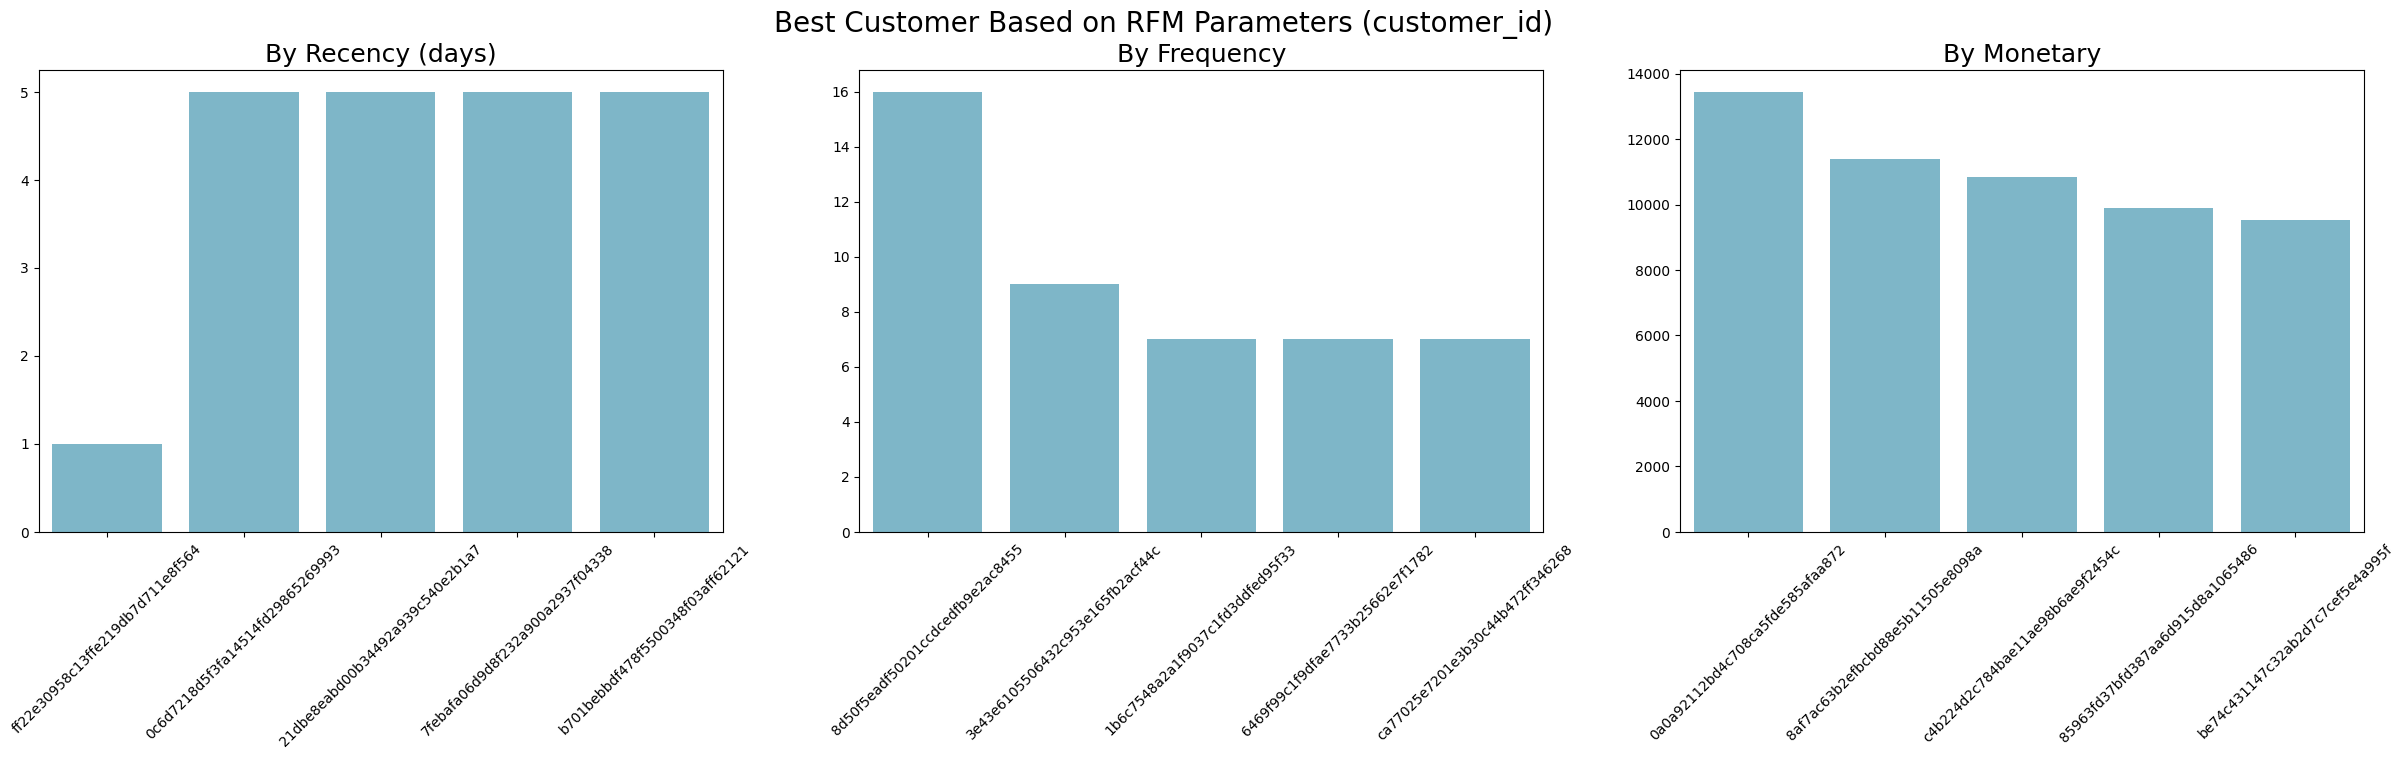

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Visualisasi Berdasarkan Recency (Hari terkecil adalah yang terbaik)
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', rotation=45)

# Visualisasi Berdasarkan Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Visualisasi Berdasarkan Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()

### Konklusi Pertanyaan 3:
Berdasarkan analisis RFM, kita dapat mengidentifikasi pelanggan yang paling baru melakukan transaksi (Recency), paling sering belanja (Frequency), dan memberikan kontribusi pendapatan terbesar (Monetary). 
- Mayoritas pelanggan di dataset ini memiliki frekuensi belanja sebanyak 1 kali, yang menunjukkan tantangan dalam retensi pelanggan.
- Strategi pemasaran dapat difokuskan pada pelanggan dengan *Recency* rendah dan *Monetary* tinggi untuk program loyalitas khusus agar mereka terus kembali bertransaksi.

### Export Data

In [10]:
# Simpan dataframe yang sudah bersih ke folder dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)